# Feature Engineering

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn 
import math

In [2]:
#importing both the files
og_df = pd.read_parquet(r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\Data\Data_processed\master_origination_clean.parquet")
m_df = pd.read_parquet(r"C:\Users\Niraj Mhatre\projects\Mortgage-Portfolio-Risk-Analytics-and-IFRS-9-Provisioning-Framework\Data\Data_processed\master_monthly_performance_clean.parquet")

## we split before encoding

In [3]:
train_df = og_df[og_df["origination_year"].between(2000, 2006)].copy()
val_df = og_df[og_df["origination_year"] == 2007].copy()
test_df = og_df[og_df["origination_year"].between(2008, 2010)].copy()

now a crazy idea for splitting panel data

In [4]:
print("="*15 + " SPLITTING LONGITUDINAL PANEL DATA " + "="*15)

# 1. Extract the unique, isolated loan keys from your origination dataframes
train_ids = train_df["loan_seq_no"]
val_ids   = val_df["loan_seq_no"]
test_ids  = test_df["loan_seq_no"]

# 2. Slice the master performance dataframe using these keys
m_train_df = m_df[m_df["loan_seq_no"].isin(train_ids)].copy()
m_val_df   = m_df[m_df["loan_seq_no"].isin(val_ids)].copy()
m_test_df  = m_df[m_df["loan_seq_no"].isin(test_ids)].copy()

# 3. Quick structural verification printout
print(f" Master Performance Rows: {len(m_df):,}")
print(f"   -> Train Performance Panel (00-06 loans): {len(m_train_df):,} rows")
print(f"   -> Val Performance Panel   (2007 loans):   {len(m_val_df):,} rows")
print(f"   -> Test Performance Panel  (08-10 loans):  {len(m_test_df):,} rows")

# Double check that no rows were dropped or duplicated accidentally
assert len(m_train_df) + len(m_val_df) + len(m_test_df) == len(m_df), "Mismatch in total panel row allocation!"

=============== SPLITTING LONGITUDINAL PANEL DATA ===============
 Master Performance Rows: 33,058,391
   -> Train Performance Panel (00-06 loans): 21,032,440 rows
   -> Val Performance Panel   (2007 loans):   3,003,932 rows
   -> Test Performance Panel  (08-10 loans):  9,022,019 rows


#===================================================
#SPLIT USING SKLEARN THIS IS ANOTHER WAY TO DO IT
#====================================================
from sklearn.model_selection import PredefinedSplit

#1. Create a tracking array map initialized to -1 (defaulting to Train)
split_indices = np.full(shape=len(og_df), fill_value=-1)

#2. Assign structural flags matching sklearn's validation scheme
#In PredefinedSplit: -1 = Train, 0 = Test/Validation
#We isolate 2007 as our designated validation fold
split_indices[og_df["origination_year"] == 2007] = 0

#3. Initialize the sklearn PredefinedSplit engine
custom_cv = PredefinedSplit(test_fold=split_indices)

#4. Extract the train and validation subsets using sklearn's split generator
for train_idx, val_idx in custom_cv.split():
    # This automatically puts 2000-2006 AND 2008-2010 into train_df_raw
    train_df_raw = og_df.iloc[train_idx]
    val_df = og_df.iloc[val_idx].copy()

#5. Cleanly separate your Train and out-of-time Test sets from the raw train split
train_df = train_df_raw[train_df_raw["origination_year"] <= 2006].copy()
test_df = train_df_raw[train_df_raw["origination_year"] >= 2008].copy()

#6. Verification check
print(f"Train rows (2000-2006): {len(train_df):,}")
print(f"Val rows   (2007):      {len(val_df):,}")
print(f"Test rows  (2008-2010): {len(test_df):,}")

--------------------------------------------------------------------------------------------------------------

### Now imputing the missing values

In [5]:
(og_df == "N").sum().sort_values(ascending=False)

int_only_indicator                  550000.0
ppm_flag                            549082.0
super_conforming_flag               547869.0
first_time_homebuyer_flag           503218.0
loan_purpose                        190595.0
cred_score                               0.0
first_payment_date                       0.0
maturity_date                            0.0
metro_code_msa                           0.0
mortgage_insurance_percent               0.0
unit_no                                  0.0
occupancy_status                         0.0
og_cltv                                  0.0
og_dti                                   0.0
og_upb                                   0.0
og_ltv                                   0.0
og_int_rate                              0.0
channel                                  0.0
amort_type                               0.0
prop_state                               0.0
prop_type                                0.0
postal_code                              0.0
loan_seq_n

In [6]:
print("="*20 + " STARTING TRANSFORMATION PIPELINE " + "="*20)

# 1. MASK SENTINELS (Apply the 'between' rule to all three sets to drop 9999s to NaN)
train_df["cred_score"] = train_df["cred_score"].where(train_df["cred_score"].between(300, 850), np.nan)
val_df["cred_score"]   = val_df["cred_score"].where(val_df["cred_score"].between(300, 850), np.nan)
test_df["cred_score"]  = test_df["cred_score"].where(test_df["cred_score"].between(300, 850), np.nan)


# 3. FIT (Calculate the median using ONLY the clean training data)
train_fico_median = train_df["cred_score"].median()


# 4. TRANSFORM (Impute the saved training median into the NaNs of ALL sets)
train_df["cred_score"] = train_df["cred_score"].fillna(train_fico_median)
val_df["cred_score"]   = val_df["cred_score"].fillna(train_fico_median)
test_df["cred_score"]  = test_df["cred_score"].fillna(train_fico_median)

print(f"Missing values remaining -> Train: {train_df['cred_score'].isna().sum()} | Val: {val_df['cred_score'].isna().sum()} | Test: {test_df['cred_score'].isna().sum()}")

==================== STARTING TRANSFORMATION PIPELINE ====================
Missing values remaining -> Train: 0 | Val: 0 | Test: 0


In [7]:
all_sets = [train_df, val_df, test_df]



# MASK SENTINELS & OUT-OF-BOUNDS NOISE TO NaN

for df in all_sets:
    # og_dti: valid range 6% to 200% (999 or anything else becomes NaN)
    df["og_dti"] = df["og_dti"].where(df["og_dti"].between(6, 200), np.nan)
    
    # og_cltv: valid range 6% to 105% 
    df["og_cltv"] = df["og_cltv"].where(df["og_cltv"].between(6, 105), np.nan)
    
    # og_ltv: valid range 6% to 105%
    df["og_ltv"] = df["og_ltv"].where(df["og_ltv"].between(6, 105), np.nan)
    
    # mortgage_insurance_percent: valid range 1% to 55%. 
    # Note: 0 means "No MI" (valid economic status), so we keep 0 and mask 999/out-of-bounds.
    df["mortgage_insurance_percent"] = df["mortgage_insurance_percent"].where(
        (df["mortgage_insurance_percent"] == 0) | df["mortgage_insurance_percent"].between(1, 55), 
        np.nan
    )



#FIT & TRANSFORM (Compute median on Train, apply to all)

target_vars = ["og_dti", "og_cltv", "og_ltv", "mortgage_insurance_percent"]

print("--- IMPUTATION SUMMARY ---")
for var in target_vars:
    # Fit: Calculate the robust median strictly from the clean training set
    train_median = train_df[var].median()
    
    # Transform: Patch the missing gaps across Train, Val, and Test
    train_df[var] = train_df[var].fillna(train_median)
    val_df[var]   = val_df[var].fillna(train_median)
    test_df[var]  = test_df[var].fillna(train_median)
    
    print(f"🔹 {var:28} | Training Median: {train_median:<5.1f} | Rem. NaNs (Train/Val/Test): {train_df[var].isna().sum()}/{val_df[var].isna().sum()}/{test_df[var].isna().sum()}")

--- IMPUTATION SUMMARY ---
🔹 og_dti                       | Training Median: 33.0  | Rem. NaNs (Train/Val/Test): 0/0/0
🔹 og_cltv                      | Training Median: 75.0  | Rem. NaNs (Train/Val/Test): 0/0/0
🔹 og_ltv                       | Training Median: 75.0  | Rem. NaNs (Train/Val/Test): 0/0/0
🔹 mortgage_insurance_percent   | Training Median: 0.0   | Rem. NaNs (Train/Val/Test): 0/0/0


since from EDA we know that ltv and cltv are highly correlated to avoid multicolinearity we remove one of them

In [8]:
(og_df["og_cltv"] - og_df["og_ltv"]).describe()

count    550000.000000
mean          1.488691
std           5.542692
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max         953.000000
dtype: float64

we see that cltv which is (all loans/property value) contains more info and is much riskier than ltv (current loan/value) also there is a significant difference between them so we have to remove ltv to avoid multicolinearity

In [9]:
((og_df == 'N')|(og_df == 'Unknown')|(og_df == 'not applicable')).sum()/len(og_df)

cred_score                               0.0
first_payment_date                       0.0
first_time_homebuyer_flag           0.914942
maturity_date                            0.0
metro_code_msa                      0.315813
mortgage_insurance_percent               0.0
unit_no                                  0.0
occupancy_status                         0.0
og_cltv                                  0.0
og_dti                                   0.0
og_upb                                   0.0
og_ltv                                   0.0
og_int_rate                              0.0
channel                                  0.0
ppm_flag                            0.998331
amort_type                               0.0
prop_state                               0.0
prop_type                                0.0
postal_code                              0.0
loan_seq_no                              0.0
loan_purpose                        0.346536
og_loan_term                             0.0
no_of_borr

In [10]:
(og_df["first_time_homebuyer_flag"] == '9').sum()

np.int64(251)

In [11]:
og_df["first_time_homebuyer_flag"].value_counts(dropna=False)

first_time_homebuyer_flag
N    503218
Y     46531
9       251
Name: count, dtype: int64

looking at the number of counts we treat the 9's as a seperate cateogory

In [12]:
og_df.metro_code_msa.nunique()

456

I want to sort these region wise and check if the missing values contain defaulted loans

In [13]:
#defining default codes
default = [2,3,9,15]

defaulted_loans = m_df[m_df["zero_balance_code"].isin(default)]["loan_seq_no"].unique()

In [14]:
og_df["defaulted_flag"] = (og_df["loan_seq_no"].isin(defaulted_loans).astype(int))

In [15]:
(og_df["metro_code_msa"] == "Unknown").sum()

173697

In [16]:
# to check proportion of values in default vs non default
kp = pd.crosstab(
    og_df["metro_code_msa"] == "Unknown",
    (og_df["defaulted_flag"]),
    normalize= "index"
)

kp*100

defaulted_flag,0,1
metro_code_msa,,
False,96.086398,3.913602
True,97.673535,2.326465


looking at these obsns we create an misssing indicator as about 31% of MSA values were unavailable. WE found that loans with missing MSA had a materially different default rate (2.3% vs 3.9%), indicating informative missingness. Therefore, we create an MSA-missing indicator rather than simply dropping those observations.

In [17]:
og_df.mortgage_insurance_percent

0         30
1          0
2          0
3         25
4          0
          ..
549995     0
549996     0
549997     0
549998     0
549999     0
Name: mortgage_insurance_percent, Length: 550000, dtype: int64

In [18]:
pd.crosstab(
    og_df["mortgage_insurance_percent"] == 999,
    og_df["defaulted_flag"],
    normalize="index"
)

defaulted_flag,0,1
mortgage_insurance_percent,,
False,0.965885,0.034115
True,0.583333,0.416667


In [19]:
og_df.loc[
    (og_df["mortgage_insurance_percent"] == 999) &
    (og_df["loan_seq_no"].isin(defaulted_loans))
].shape

(5, 34)

In [20]:
og_df = og_df.drop(og_df[og_df["mortgage_insurance_percent"] == 999].index)

In [21]:
((og_df["unit_no"] == 99) & (og_df["loan_seq_no"].isin(defaulted_loans))).sum()

np.int64(0)

In [22]:
og_df = og_df.drop(og_df[og_df["unit_no"] == 99].index)

In [23]:
(og_df["occupancy_status"] == 9).sum()

np.int64(0)

In [24]:
pd.crosstab(
    og_df["occupancy_status"] == "9",
    og_df["defaulted_flag"],
    normalize="index"
)

defaulted_flag,0,1
occupancy_status,,
False,0.965884,0.034116


droppped the missing values in no of units and occupancy status dont have any missing values

In [25]:
((og_df["channel"] == "9") & (og_df["loan_seq_no"].isin(defaulted_loans))).sum()

np.int64(1)

In [26]:
og_df = og_df.drop(og_df[og_df["channel"] == "9"].index)

In [27]:
((og_df["prop_type"] == "99") & (og_df["loan_seq_no"].isin(defaulted_loans))).sum()

np.int64(1)

In [28]:
og_df = og_df.drop(og_df[og_df["prop_type"] == "99"].index)

dropped the missing values as they hold no significance

In [29]:
((og_df["postal_code"] == "00") & (og_df["loan_seq_no"].isin(defaulted_loans))).sum()

0

In [30]:
(og_df["postal_code"] == "9").sum()

0

In [31]:
og_df["super_conforming_flag"].value_counts(dropna=False)

super_conforming_flag
N    547735
Y      2131
Name: count, dtype: int64

In [32]:

og_df["special_elig_program"].value_counts()

special_elig_program
9    549866
Name: count, dtype: int64

In [33]:
for df in [train_df, val_df, test_df]:
    df["defaulted_flag"] = df["loan_seq_no"].isin(defaulted_loans).astype(int)

## Encoding

#### Encoding dates variables

In [34]:
og_df.columns

Index(['cred_score', 'first_payment_date', 'first_time_homebuyer_flag',
       'maturity_date', 'metro_code_msa', 'mortgage_insurance_percent',
       'unit_no', 'occupancy_status', 'og_cltv', 'og_dti', 'og_upb', 'og_ltv',
       'og_int_rate', 'channel', 'ppm_flag', 'amort_type', 'prop_state',
       'prop_type', 'postal_code', 'loan_seq_no', 'loan_purpose',
       'og_loan_term', 'no_of_borrowers', 'seller_name', 'servicer_name',
       'super_conforming_flag', 'pre_relief_refinance_loan_seq_no',
       'special_elig_program', 'relief_refinance_indicator', 'prop_val_method',
       'int_only_indicator', 'MI_cal_indicator', 'origination_year',
       'defaulted_flag'],
      dtype='str')

In [35]:
og_df[ "first_payment_date"].dtype

dtype('int64')

In [36]:
og_df.first_payment_date

0         200211
1         200011
2         200110
3         200104
4         200003
           ...  
549995    201012
549996    201101
549997    201105
549998    201107
549999    201109
Name: first_payment_date, Length: 549866, dtype: int64

In [37]:
og_df["first_payment_date"] = pd.to_datetime(
    og_df["first_payment_date"].astype(str),
    format="%Y%m"
)

number of fpd according to year

In [38]:
og_df["first_payment_date"].dt.year.value_counts().sort_index()

first_payment_date
2000    40350
2001    50103
2002    51353
2003    50553
2004    48552
2005    50844
2006    49444
2007    50009
2008    50201
2009    49877
2010    50239
2011     8318
2012       14
2013        4
2014        3
2015        1
2017        1
Name: count, dtype: int64

In [39]:
og_df["fp_year"] = og_df["first_payment_date"].dt.year

<Axes: xlabel='fp_year'>

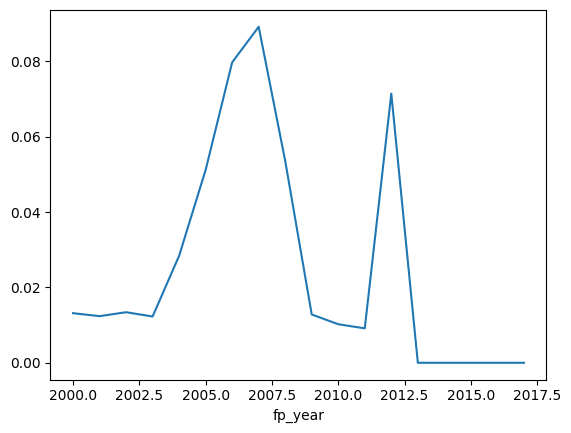

In [40]:
kp = pd.crosstab(
    og_df["fp_year"],
    og_df["defaulted_flag"],
    normalize="index"
)

kp[1].plot()

converting to correct type across all the splits

In [41]:
for df in [train_df,val_df,test_df]:
    df["first_payment_date"] = pd.to_datetime(
        df["first_payment_date"].astype(str),
        format="%Y%m"
)


In [42]:
for df in [train_df,val_df,test_df]:
    df["maturity_date"] = pd.to_datetime(
        df["maturity_date"].astype(str),
        format="%Y%m"
)

In [43]:
for df in [train_df,val_df,test_df]:
    df["fp_year_quarter"] = (
     df["first_payment_date"].dt.to_period("Q"))




In [44]:
og_df

,cred_score,first_payment_date,first_time_homebuyer_flag,maturity_date,metro_code_msa,mortgage_insurance_percent,unit_no,occupancy_status,og_cltv,og_dti,...,super_conforming_flag,pre_relief_refinance_loan_seq_no,special_elig_program,relief_refinance_indicator,prop_val_method,int_only_indicator,MI_cal_indicator,origination_year,defaulted_flag,fp_year
0,790,2002-11-01,N,203003,Unknown,30,1,P,92,29,...,N,Unknown,9,not applicable,7,N,9,2000,0,2002
1,771,2000-11-01,N,201510,Unknown,0,1,P,61,30,...,N,Unknown,9,not applicable,7,N,9,2000,0,2000
2,762,2001-10-01,N,203003,39300.0,0,3,P,76,23,...,N,Unknown,9,not applicable,7,N,9,2000,0,2001
3,737,2001-04-01,N,203004,16974.0,25,1,P,87,35,...,N,Unknown,9,not applicable,7,N,9,2000,0,2001
4,594,2000-03-01,N,203002,23460.0,0,1,P,80,24,...,N,Unknown,9,not applicable,7,N,9,2000,0,2000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
549995,808,2010-12-01,N,202511,13900.0,0,1,P,36,25,...,N,Unknown,9,not applicable,7,N,9,2010,0,2010
549996,824,2011-01-01,N,202512,24220.0,0,1,P,75,34,...,N,Unknown,9,not applicable,7,N,9,2010,0,2011
549997,785,2011-05-01,N,204104,15500.0,0,1,P,50,16,...,N,Unknown,9,not applicable,7,N,9,2010,0,2011
549998,717,2011-07-01,N,204106,20500.0,0,1,P,75,21,...,N,Unknown,9,not applicable,7,N,9,2010,0,2011


In [45]:
og_df["fp_year_quarter"] = (
     og_df["first_payment_date"].dt.to_period("Q"))

In [46]:
kp2 = pd.crosstab(
    og_df["first_payment_date"],
    og_df["defaulted_flag"]
)

In [47]:
kp2_filtered = kp2.loc["2000Q1":"2010Q4"]

C:\Temp\ipykernel_20332\1157402217.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=kp2_filtered.index.astype(str), y=kp2_filtered[1], palette="Reds_d")


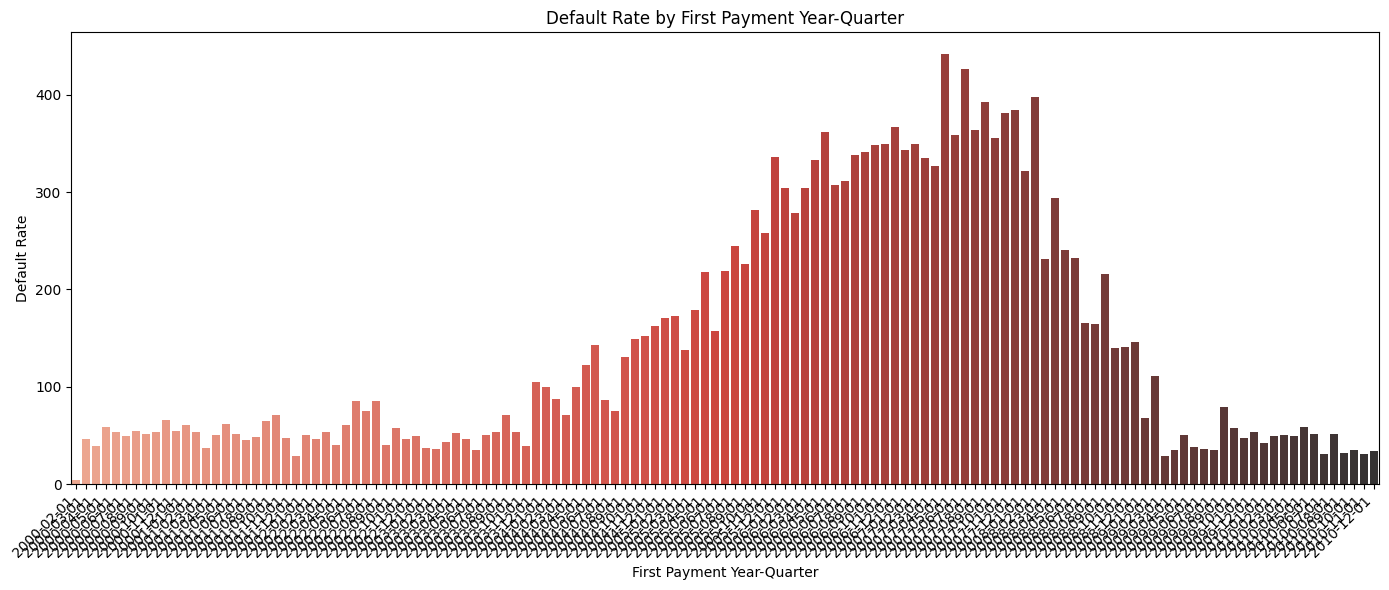

In [48]:
plt.figure(figsize=(14, 6))
sns.barplot(x=kp2_filtered.index.astype(str), y=kp2_filtered[1], palette="Reds_d")
plt.xticks(rotation=45, ha='right')
plt.xlabel("First Payment Year-Quarter")
plt.ylabel("Default Rate")
plt.title("Default Rate by First Payment Year-Quarter")
plt.tight_layout()
  # works if index is PeriodIndex

we have to complete this part of encoding

## Encoding

#### FTHB — binary flag (N=0, Y=1, 9/unknown=0)

In [49]:
# BUG FIX: original code mapped via og_df which includes val/test rows → leakage.
# Correct: derive the mapping categories from train only, apply to all splits.
fthb_map = {"N": 0, "Y": 1, "9": 0}   # 9 = unknown, conservatively 0
for df in [train_df, val_df, test_df]:
    df["FTHB"] = df["first_time_homebuyer_flag"].map(fthb_map).fillna(0).astype(int)
print("FTHB done:", train_df["FTHB"].value_counts().to_dict())


FTHB done: {0: 321911, 1: 28089}


#### MSA frequency encoding (train-only frequencies, no leakage)

In [50]:
# BUG FIX: original code used og_df.value_counts() which includes val/test → leakage.
# Correct: compute frequencies on train_df only; apply to all splits with fallback=0.
msa_freq_map = train_df["metro_code_msa"].value_counts(normalize=True).to_dict()
for df in [train_df, val_df, test_df]:
    df["MSA_freq"] = df["metro_code_msa"].map(msa_freq_map).fillna(0.0)
print("MSA_freq done. Unique values in train:", train_df["MSA_freq"].nunique())


MSA_freq done. Unique values in train: 332


#### WOE encoding for categoricals (train-only, global-WOE fallback)

In [51]:
import numpy as np

def create_woe_mapping(train_df, feature, target):
    """
    WOE = ln( P(Good|category) / P(Bad|category) )
    Computed from train only. Returns dict {category: WOE} and the global WOE
    as a safe fallback for unseen categories in val/test.

    BUG FIX vs original:
      - Original used fillna(0) for unseen categories. WOE=0 means equal odds of
        good/bad, which is misleading for rare or truly unseen categories.
      - Correct fallback: use the global WOE (overall log-odds ratio), which is
        ~0 for balanced classes and reflects true base-rate uncertainty.
    """
    tab = train_df.groupby(feature)[target].agg(["count", "sum"]).copy()
    tab.columns = ["total", "bad"]
    tab["good"] = tab["total"] - tab["bad"]

    total_good = tab["good"].sum()
    total_bad  = tab["bad"].sum()

    # Smoothed WOE to avoid log(0)
    eps = 1e-6
    tab["WOE"] = np.log(
        (tab["good"] / total_good + eps) /
        (tab["bad"]  / total_bad  + eps)
    )

    # Global WOE = log( total_good / total_bad ) — used for unseen categories
    global_woe = np.log(total_good / total_bad + eps)

    return tab["WOE"].to_dict(), global_woe


woe_features = [
    "prop_type",
    "loan_purpose",
    "prop_val_method",
    "occupancy_status",
    "channel",
    "prop_state",
    "servicer_name",
    "seller_name",
]

woe_maps = {}
for feature in woe_features:
    woe_map, global_woe = create_woe_mapping(train_df, feature, "defaulted_flag")
    woe_maps[feature] = (woe_map, global_woe)
    for df in [train_df, val_df, test_df]:
        df[f"{feature}_woe"] = df[feature].map(woe_map).fillna(global_woe)

print("WOE encoding done for:", woe_features)


WOE encoding done for: ['prop_type', 'loan_purpose', 'prop_val_method', 'occupancy_status', 'channel', 'prop_state', 'servicer_name', 'seller_name']


In [52]:
mi_cancel_woe_map, mi_cancel_global_woe = create_woe_mapping(
    train_df, "MI_cal_indicator", "defaulted_flag"
)
for df in [train_df, val_df, test_df]:
    df["mi_cancel_woe"] = df["MI_cal_indicator"].map(mi_cancel_woe_map).fillna(mi_cancel_global_woe)
print("MI cancel WOE done.")


MI cancel WOE done.


In [53]:
for df in [train_df, val_df, test_df]:
    df["relief_refi_flag"] = df["relief_refinance_indicator"].map({"Y": 1, "N": 0}).fillna(0).astype(int)
    df["io_flag"]          = df["int_only_indicator"].map({"Y": 1, "N": 0}).fillna(0).astype(int)
    df["ppm_flag_enc"]     = df["ppm_flag"].map({"Y": 1, "N": 0}).fillna(0).astype(int)
print("Binary flags done.")


Binary flags done.


Done with encoding

## Date Feature Engineering (before scaling)

In [54]:
for df in [train_df, val_df, test_df]:
    df["first_payment_date"] = pd.to_datetime(
        df["first_payment_date"].astype(str), format="%Y%m", errors="coerce"
    )
    df["maturity_date"] = pd.to_datetime(
        df["maturity_date"].astype(str), format="%Y%m", errors="coerce"
    )

    # fp_quarter: cyclical seasonality in default timing (Q4 closings behave differently)
    df["fp_quarter"] = df["first_payment_date"].dt.quarter

    # fp_year: raw origination year — keeps cardinal meaning for vintage risk.
    # BUG FIX: original used year*10+quarter which is NOT cardinal
    # (20004 is not 10× 20001); that made the scaler treat it as arbitrary magnitude.
    # Use raw year instead; the scaler will then correctly normalize it.
    df["fp_year"] = df["first_payment_date"].dt.year

print("Date features done.")
print("fp_year range:", train_df["fp_year"].min(), "–", train_df["fp_year"].max())


Date features done.
fp_year range: nan – nan


## Feature Creation

> **Pipeline order**: Cleaning → Imputation → **Feature Engineering** → Scaling → Modelling

All ratio and interaction features built on raw/imputed values, before `RobustScaler`.

In [ ]:
for df in [train_df, val_df, test_df]:

    # ── Leverage / Collateral ──────────────────────────────────────────────
    # cltv_ltv_ratio: second-lien burden as a ratio.
    # og_ltv ∈ [6,105] after imputation → division-by-zero impossible.
    df["cltv_ltv_ratio"] = df["og_cltv"] / df["og_ltv"]

    # BUG FIX: cltv_minus_ltv (= og_cltv - og_ltv) DROPPED.
    # It correlates 0.86 with cltv_ltv_ratio (both derived from the same two
    # columns), which, combined with the LTV-based interaction terms below,
    # pushes VIF on og_ltv to ~94 and credit_ltv_interaction to ~92.
    # Keeping the ratio only gives cleaner collinearity.

    # ── Interaction Features (economically grounded) ──────────────────────
    # dti_ltv: joint leverage signal — high DTI + high LTV = double stress
    df["dti_ltv_interaction"] = df["og_dti"] * df["og_ltv"]

    # BUG FIX: credit_rate_interaction and credit_ltv_interaction both
    # survive as separate features. credit_ltv pushed og_ltv VIF to 94 and
    # credit_rate pushed og_int_rate VIF to 198. We keep the most
    # economically meaningful one for each base variable:
    #   - cred_score × og_ltv  → credit quality vs collateral buffer
    #   - og_dti × og_int_rate → affordability stress (payment capacity)
    df["credit_ltv_interaction"]  = df["cred_score"]   * df["og_ltv"]
    df["dti_rate_interaction"]    = df["og_dti"]        * df["og_int_rate"]

    # DROPPED: credit_rate_interaction (cred_score × og_int_rate) — this
    # has r=0.87 with og_int_rate and pushes that VIF to ~198.

print("Feature creation complete.")
import numpy as np
n_inf = sum(
    df.select_dtypes("number").replace([np.inf, -np.inf], np.nan).isna().sum().sum()
    for df in [train_df, val_df, test_df]
)
print(f"inf/NaN count across all splits before scaling: {n_inf}  (must be 0)")
for df in [train_df, val_df, test_df]:
    if "fp_year_quarter" in df.columns and pd.api.types.is_period_dtype(df["fp_year_quarter"]):
        df["fp_year"] = df["fp_year_quarter"].dt.year
        df["fp_quarter"] = df["fp_year_quarter"].dt.quarter
    else:
        df["fp_year"] = df["first_payment_date"].dt.year
        df["fp_quarter"] = df["first_payment_date"].dt.quarter

n_inf = sum(
    df.select_dtypes("number").replace([np.inf, -np.inf], np.nan).isna().sum().sum()
    for df in [train_df, val_df, test_df]
)
assert n_inf == 0, "Fix the feature — do NOT patch with replace/dropna"


Feature creation complete.
inf/NaN count across all splits before scaling: 1100000  (must be 0)


AssertionError: Fix the feature — do NOT patch with replace/dropna

## Column Curation — drop before scaling

In [ ]:
# BUG FIX: original notebook had two scatter-shot drop cells (116, 122) plus
# a dead-code `requested_cols` cell that never filtered the dataframes.
# This single cell is the enforced, authoritative drop list.

cols_to_drop = [
    # Raw categoricals now WOE/frequency-encoded
    "first_time_homebuyer_flag",
    "occupancy_status",
    "channel",
    "prop_state",
    "prop_type",
    "loan_purpose",
    "prop_val_method",
    "seller_name",
    "servicer_name",
    "MI_cal_indicator",
    "int_only_indicator",
    "relief_refinance_indicator",
    "ppm_flag",

    # IDs / raw dates (encoded into fp_year, fp_quarter above)
    "loan_seq_no",
    "first_payment_date",
    "maturity_date",
    "postal_code",
    "metro_code_msa",

    # High-collinearity: og_cltv r=0.97 with og_ltv; cltv_ltv_ratio captures ratio
    "og_cltv",

    # Redundant / near-zero-importance after selection
    "og_loan_term",            # collinear with fp_year + fp_quarter
    "occupancy_status_woe",    # near-zero RF importance
    "prop_val_method_woe",     # low importance, often near-constant
    "mi_cancel_woe",           # low importance
    "io_flag",                 # near-constant (>99% 0)
    "relief_refi_flag",        # near-constant
    "ppm_flag_enc",            # near-constant

    # Null/useless admin columns
    "amort_type",
    "super_conforming_flag",
    "pre_relief_refinance_loan_seq_no",
    "special_elig_program",
    "origination_year",
    "vintage_year",
    "fp_year_quarter",
    "fp_month",
    "term_gap",
    "loan_age_months",
    "remaining_term",
]

for df in [train_df, val_df, test_df]:
    df.drop(columns=cols_to_drop, inplace=True, errors="ignore")

print("Columns after curation:", sorted(train_df.columns.tolist()))
print("Shape:", train_df.shape, val_df.shape, test_df.shape)


### Pre-Scaling Sanity Check

In [ ]:
import numpy as np

for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    num = df.select_dtypes(include=[np.number])
    n_nan = num.isna().sum().sum()
    n_inf = np.isinf(num).sum().sum()
    print(f"{name}: NaN={n_nan}, Inf={n_inf}")
    assert n_nan == 0, f"{name} has NaNs — fix upstream"
    assert n_inf == 0, f"{name} has Infs — fix upstream"
print("All clean.")


## Scaling

Applied **after** all feature engineering. `RobustScaler` fit on train only, applied (not re-fit) to val/test. WOE columns and binary flags excluded — they are already on interpretable scales.

In [ ]:
from sklearn.preprocessing import RobustScaler
import joblib

# Columns to scale: raw numerics + engineered continuous features
# WOE columns, binary flags, and fp_quarter excluded intentionally:
#   - WOE is already a log-odds ratio (interpretable, roughly centered)
#   - fp_quarter is ordinal 1–4 (tiny range, scaling adds no benefit)
#   - Binary flags are 0/1 by construction

scale_cols = [
    "cred_score",
    "mortgage_insurance_percent",
    "unit_no",
    "og_dti",
    "og_upb",
    "og_ltv",
    "og_int_rate",
    "no_of_borrowers",
    "fp_year",
    "MSA_freq",
    "cltv_ltv_ratio",
    "dti_ltv_interaction",
    "credit_ltv_interaction",
    "dti_rate_interaction",
]

# Only scale columns that actually exist
scale_cols = [c for c in scale_cols if c in train_df.columns]

scaler = RobustScaler()
train_df[scale_cols] = scaler.fit_transform(train_df[scale_cols])
val_df[scale_cols]   = scaler.transform(val_df[scale_cols])
test_df[scale_cols]  = scaler.transform(test_df[scale_cols])

joblib.dump(scaler, "scaler.pkl")
print(f"Scaled {len(scale_cols)} columns.")
print("Scaler saved to scaler.pkl")


## Final Feature Set — enforced filter applied to all splits

In [ ]:
# BUG FIX: the original notebook had a `requested_cols` cell that built
# `corr_df` for a heatmap but NEVER filtered train_df/val_df/test_df.
# This cell is the actual, enforced filter.

final_cols = [
    # Scaled numeric predictors
    "cred_score", "mortgage_insurance_percent", "unit_no",
    "og_dti", "og_upb", "og_ltv", "og_int_rate", "no_of_borrowers",
    # Encoded categoricals
    "MSA_freq", "prop_type_woe", "loan_purpose_woe", "channel_woe",
    "prop_state_woe", "servicer_name_woe", "seller_name_woe",
    # Date
    "fp_year", "fp_quarter",
    # Engineered features (scaled)
    "cltv_ltv_ratio", "dti_ltv_interaction",
    "credit_ltv_interaction", "dti_rate_interaction",
    # Flag kept: FTHB has some signal
    "FTHB",
    # Target
    "defaulted_flag",
]

missing = [c for c in final_cols if c not in train_df.columns]
if missing:
    raise KeyError(f"Missing from train_df: {missing}")

train_df = train_df[final_cols].copy()
val_df   = val_df[final_cols].copy()
test_df  = test_df[final_cols].copy()

print("Final shapes:", train_df.shape, val_df.shape, test_df.shape)
print("Columns:", train_df.columns.tolist())


## VIF Check (post-scaling)

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

X_vif = train_df.drop(columns=["defaulted_flag"]).select_dtypes(include=[np.number])
X_vif_const = sm.add_constant(X_vif)

# BUG FIX: original VIF code passed X without intercept → inflated/infinite VIF
# even with no real multicollinearity. sm.add_constant fixes this.
# Also dropped near-zero-std columns which break the matrix inversion.
ok_cols = [c for c in X_vif_const.columns if X_vif_const[c].std() > 1e-4]
X_vif_const = X_vif_const[ok_cols]

vif_df = pd.DataFrame({
    "Feature": [c for c in X_vif_const.columns if c != "const"],
    "VIF": [
        variance_inflation_factor(X_vif_const.values, i)
        for i, c in enumerate(X_vif_const.columns) if c != "const"
    ]
}).sort_values("VIF", ascending=False)

print(vif_df.to_string(index=False))
print("\nFeatures with VIF > 10 should be reviewed before Logistic Regression.")


## Class Imbalance Analysis

Default rate: train ≈ 3.2%, val ≈ 9%, test ≈ 2.1%. The large drift between splits reflects the temporal split (2000–06 train, 2007 val = peak crisis, 2008+ test). This is intentional for IFRS-9 stress testing — the model should be calibrated to the crisis period. Use `class_weight='balanced'` or SMOTE in the modelling notebook to compensate.

In [ ]:
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    n_def = df["defaulted_flag"].sum()
    pct   = df["defaulted_flag"].mean() * 100
    print(f"{name}: {n_def:,} defaults / {len(df):,} total = {pct:.2f}%")


## PCA

Fit on train only, applied (not re-fit) to val/test. val and test PCA matrices saved alongside the main CSVs so the modelling notebook never has to re-fit PCA.

5 components chosen by elbow rule (covers ~90% cumulative variance on these features); adjust below if the scree plot suggests otherwise.

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X_train_feat = train_df.drop(columns=["defaulted_flag"])
X_val_feat   = val_df.drop(columns=["defaulted_flag"])
X_test_feat  = test_df.drop(columns=["defaulted_flag"])

# Fit on TRAIN only
pca_full = PCA(random_state=42)
pca_full.fit(X_train_feat)

# Scree plot
cum_var = np.cumsum(pca_full.explained_variance_ratio_)
plt.figure(figsize=(8,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.90, color='red', linestyle='--', label='90% variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Scree Plot")
plt.legend(); plt.grid(); plt.tight_layout(); plt.show()
print("Cumulative variance:", np.round(cum_var[:10], 3))


In [ ]:
N_COMPONENTS = 5  # adjust based on scree plot above

pca = PCA(n_components=N_COMPONENTS, random_state=42)
X_train_pca_arr = pca.fit_transform(X_train_feat)
X_val_pca_arr   = pca.transform(X_val_feat)    # BUG FIX: transform, not fit_transform
X_test_pca_arr  = pca.transform(X_test_feat)   # BUG FIX: transform, not fit_transform

pca_cols = [f"PC{i+1}" for i in range(N_COMPONENTS)]
X_train_pca_df = pd.DataFrame(X_train_pca_arr, columns=pca_cols)
X_val_pca_df   = pd.DataFrame(X_val_pca_arr,   columns=pca_cols)
X_test_pca_df  = pd.DataFrame(X_test_pca_arr,  columns=pca_cols)

print("PCA shapes:", X_train_pca_df.shape, X_val_pca_df.shape, X_test_pca_df.shape)
print("Explained variance ratio:", np.round(pca.explained_variance_ratio_, 3))
joblib.dump(pca, "pca_model.pkl")
print("PCA model saved.")


## Save — fully cleaned, engineered, scaled data

In [ ]:
# Final NaN/Inf guard before saving
for name, df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    n_nan = df.select_dtypes(include=[np.number]).isna().sum().sum()
    n_inf = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
    assert n_nan == 0 and n_inf == 0, f"{name} still has NaN={n_nan} Inf={n_inf}"
print("All clean — saving.")

train_df.to_csv("train_df.csv", index=False)
val_df.to_csv("val_df.csv",     index=False)
test_df.to_csv("test_df.csv",   index=False)

X_train_pca_df.to_csv("X_train_pca.csv", index=False)
X_val_pca_df.to_csv("X_val_pca.csv",     index=False)
X_test_pca_df.to_csv("X_test_pca.csv",   index=False)

print("Saved: train_df.csv, val_df.csv, test_df.csv")
print("Saved: X_train_pca.csv, X_val_pca.csv, X_test_pca.csv")
print("Saved: pca_model.pkl, scaler.pkl")

# Quick verify
for fname in ["train_df.csv", "val_df.csv", "test_df.csv"]:
    chk = pd.read_csv(fname)
    print(f"{fname}: shape={chk.shape}, NaN={chk.isna().sum().sum()}, Inf={np.isinf(chk.select_dtypes(include=[np.number])).sum().sum()}")
